In [7]:

from sunpy.net import Fido, attrs as a
from stixpy.net.client import STIXClient  # This registers the STIX client with Fido

start_time = "2024-05-14T04:00:00"
end_time = "2024-05-14T06:00:00"

ql_query = Fido.search(a.Time(start_time, end_time), 
                       a.Instrument.stix,
                       a.stix.DataProduct.ql_lightcurve)
ql_query





Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str2,str13,str3,str1
2024-05-14 00:00:00.000,2024-05-14 23:59:59.999,STIX,L1,QL,ql-lightcurve,V02,-


In [6]:
# Downloading the datasets 
ql_files = Fido.fetch(ql_query)
print("Downloaded STIX Files:", ql_files)
ql_files 

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Downloaded STIX Files: ['/home/jashhwanth/sunpy/data/solo_L1_stix-ql-lightcurve_20240514_V02.fits']


['/home/jashhwanth/sunpy/data/solo_L1_stix-ql-lightcurve_20240514_V02.fits']

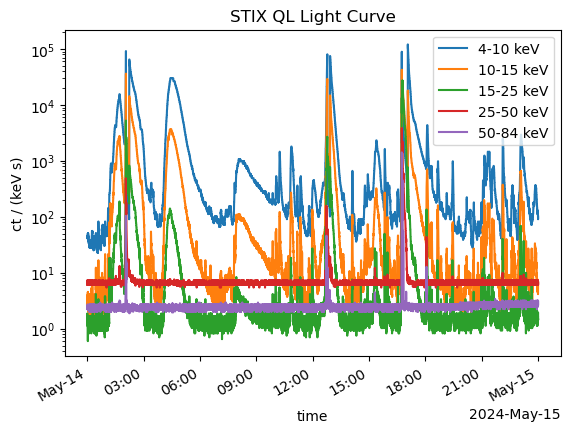

                         control_index  timedel  triggers  triggers_comp_err  \
time                                                                           
2024-05-14 00:00:02.076              0    400.0      3455          73.901962   
2024-05-14 00:00:06.076              0    400.0      3967          73.901962   
2024-05-14 00:00:10.076              0    400.0      3711          73.901962   
2024-05-14 00:00:14.076              0    400.0      3455          73.901962   
2024-05-14 00:00:18.076              0    400.0      3455          73.901962   

                         rcr   4-10 keV  10-15 keV  15-25 keV  25-50 keV  \
time                                                                       
2024-05-14 00:00:02.076    0  45.319068   3.051845   1.525923   6.714059   
2024-05-14 00:00:06.076    0  45.323131   3.752605   1.325920   7.355106   
2024-05-14 00:00:10.076    0  45.321099   3.752437   1.225796   6.714360   
2024-05-14 00:00:14.076    0  45.319068   3.352027   1.3258

In [8]:
# Loading STIX X-ray time series

from datetime import datetime
from sunpy.timeseries import TimeSeries
from stixpy.timeseries import quicklook # This registers the STIX timeseries with sunpy
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, ScalarFormatter


ql_lightcurves = TimeSeries(ql_files)

ql_lightcurves.peek()

print(ql_lightcurves.to_dataframe().head())

print("Time Range:", ql_lightcurves.time_range)  # Check the actual available time range

print(ql_lightcurves.columns) 

In [78]:
## Science Data (Pixel data format)

from astropy.io import fits

data_dir = '/home/jashhwanth/Desktop/solarflare/14_May_2024_New/' 
fits_filename = data_dir+'solo_L1_stix-sci-xray-cpd_20240514T162700-20240514T190550_V02_2405143076-50414.fits'

# open the fits file
hdulist=fits.open(fits_filename)
header=hdulist[2].header
print(header)

# parse time which is given as seconds since the beginning of the observation
time_sod=hdulist[2].data.field('time')
print(time_sod)


# parse counts - (time, 32 detectors, 12 pixels, 32 energy bins)
counts = hdulist[2].data.field('counts')
#print(counts.shape)


print(hdulist[4].columns.names)
# produce energy labels
energy_labels = [str(x)+'-'+str(y)+' keV' for x,y in zip(hdulist[4].data['e_low'],hdulist[4].data['e_high'])]

# read energy information
energy_edges = [e_low+(e_high-e_low) for chn,e_low,e_high in hdulist[4].data]
energy_edges.insert(0,0)
mean_energy = [(e_high+e_low)/2 for chn,e_low,e_high in hdulist[4].data]

print(energy_edges)
print(mean_energy)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                41655 / length of dimension 1                          NAXIS2  =                  473 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                   11 / number of table fields                         TTYPE1  = 'time    '                                                            TFORM1  = 'J       '                                                            TUNIT1  = 'cs      '                                                            TSCAL1  =                    1                                                  TZERO1  =           2147483648          

In [97]:
## Create time array

from functools import partial
from datetime import datetime
from datetime import timedelta

def convert_seconds_datetime(sod_i, date_obs):
    # Handle fractional seconds (milliseconds or microseconds)
    if '.' in date_obs:
        date, frac = date_obs.split('.')
        frac = (frac + "000000")[:6]  # Ensure microseconds are 6 digits
        date_obs = f"{date}.{frac}"
        fmt = '%Y-%m-%dT%H:%M:%S.%f'
    else:
        fmt = '%Y-%m-%dT%H:%M:%S'

    try:
        dt = datetime.strptime(date_obs, fmt)
        return dt + timedelta(seconds=int(sod_i))  # ✅ Fix: convert to Python int
    except Exception as e:
        print(f"Error parsing {date_obs} with sod_i={sod_i}: {e}")
        return None

date_obs = hdulist[0].header['DATE-BEG']
map_func = partial(convert_seconds_datetime, date_obs=date_obs)
time_arr = np.asarray([map_func(sod) for sod in time_sod])

print(time_arr[0])

print(len(time_sod))  # This should match the number of time steps, likely 503
print(len(time_arr))

print("DATE-BEG:", hdulist[0].header['DATE-BEG'])

print(time_arr[0:])   # print first few entries
print(type(time_arr[0])) 


2024-05-14 16:44:00.784000
473
473
DATE-BEG: 2024-05-14T16:27:00.784
[datetime.datetime(2024, 5, 14, 16, 44, 0, 784000)
 datetime.datetime(2024, 5, 14, 17, 17, 55, 784000)
 datetime.datetime(2024, 5, 14, 17, 51, 45, 784000)
 datetime.datetime(2024, 5, 14, 18, 26, 40, 784000)
 datetime.datetime(2024, 5, 14, 19, 3, 10, 784000)
 datetime.datetime(2024, 5, 14, 19, 40, 20, 784000)
 datetime.datetime(2024, 5, 14, 20, 18, 25, 784000)
 datetime.datetime(2024, 5, 14, 20, 54, 55, 784000)
 datetime.datetime(2024, 5, 14, 21, 28, 55, 784000)
 datetime.datetime(2024, 5, 14, 22, 3, 5, 784000)
 datetime.datetime(2024, 5, 14, 22, 37, 25, 784000)
 datetime.datetime(2024, 5, 14, 23, 11, 20, 784000)
 datetime.datetime(2024, 5, 14, 23, 45, 0, 784000)
 datetime.datetime(2024, 5, 15, 0, 18, 55, 784000)
 datetime.datetime(2024, 5, 15, 0, 53, 0, 784000)
 datetime.datetime(2024, 5, 15, 1, 26, 50, 784000)
 datetime.datetime(2024, 5, 15, 2, 0, 20, 784000)
 datetime.datetime(2024, 5, 15, 2, 34, 10, 784000)
 dateti

In [98]:
## Produce lightcurves of counts summed on all pixels for each detectors:

counts_det = counts.sum(axis=2)

In [99]:
## Plot lightcurves for all detectors, in the second energy band

eband=26
counts_det_oneband = counts_det[:,:,eband]

print(eband)
print(counts_det_oneband)

26
[[30 31 31 ... 30 24 31]
 [34 38 36 ... 32 28 24]
 [39 33 32 ... 26 26 28]
 ...
 [26 28 33 ... 32 33 30]
 [27 38 31 ... 47 38 27]
 [30 31 41 ... 34 24 27]]


[19857.6972313  19857.72078454 19857.74427991 19857.76852759
 19857.79387481]
[19868.60446509 19868.62992806 19868.65521741 19868.6806225
 19868.70440722]
[datetime.datetime(2024, 5, 14, 16, 44, 0, 784000)
 datetime.datetime(2024, 5, 14, 17, 17, 55, 784000)
 datetime.datetime(2024, 5, 14, 17, 51, 45, 784000)
 datetime.datetime(2024, 5, 14, 18, 26, 40, 784000)
 datetime.datetime(2024, 5, 14, 19, 3, 10, 784000)]
[datetime.datetime(2024, 5, 25, 14, 30, 25, 784000)
 datetime.datetime(2024, 5, 25, 15, 7, 5, 784000)
 datetime.datetime(2024, 5, 25, 15, 43, 30, 784000)
 datetime.datetime(2024, 5, 25, 16, 20, 5, 784000)
 datetime.datetime(2024, 5, 25, 16, 54, 20, 784000)]


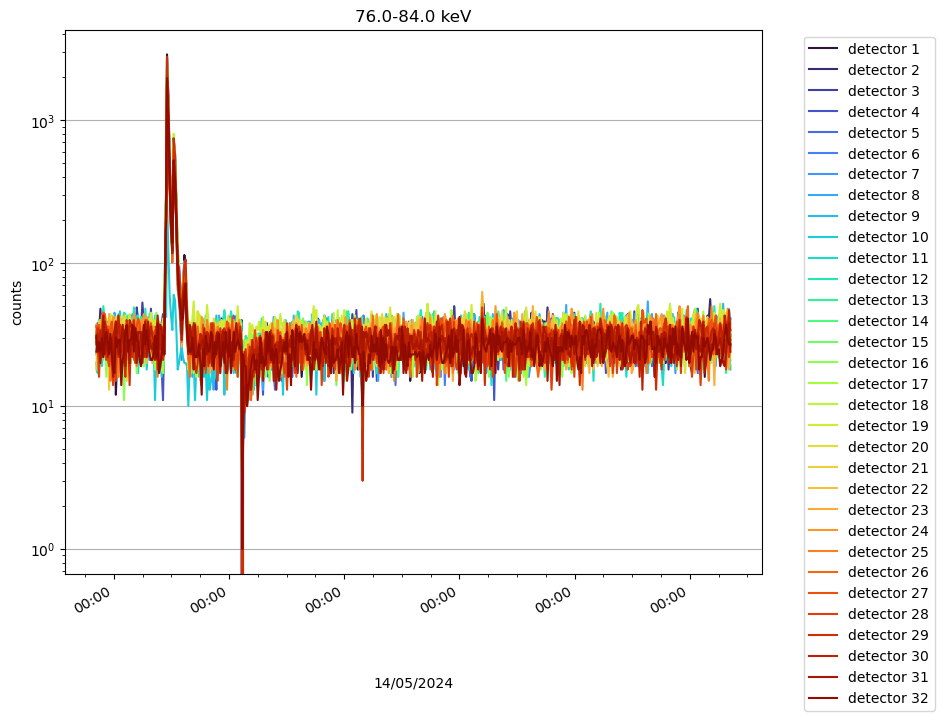

In [100]:
import matplotlib.pyplot as plt
import matplotlib.dates as plt_dates
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.dates import MinuteLocator, DateFormatter
from datetime import datetime


# Convert datetime array to matplotlib date format
hxr_dates = plt_dates.date2num(time_arr)
print(hxr_dates[:5])  # Optional: to verify the date conversion
print(hxr_dates[-5:]) 
print(time_arr[:5])
print(time_arr[-5:])

hxr_counts = counts_det_oneband

fig = plt.figure(figsize=(9,8),facecolor='w')
axes = fig.subplots(nrows=1,ncols=1)
cm = plt.get_cmap('turbo')
num_colors = counts_det_oneband.shape[1]

dets = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]
labels = ['detector '+str(ii) for ii in dets]

for chan in range(hxr_counts.shape[1]):
    lines = axes.plot(hxr_dates,hxr_counts[:,chan],label=labels[chan])
    lines[0].set_color(cm(1.*chan/num_colors))

axes.minorticks_on()
axes.yaxis.set_minor_locator(mticker.MultipleLocator(5))
axes.set_yscale("log")
axes.set_ylabel('counts')
axes.yaxis.grid(True, 'major')
# Format x-axis as time
axes.xaxis_date()
axes.xaxis.set_major_locator(plt_dates.AutoDateLocator(minticks=3, maxticks=10))  # auto limits ticks
axes.xaxis.set_major_formatter(DateFormatter('%H:%M'))
fig.autofmt_xdate()  # Rotate tick labels if necessary

# Add observation date below the plot
axes.text(0.5, -0.2, datetime.strftime(time_arr[5], "%d/%m/%Y"),
          ha='center', va='center', transform=axes.transAxes)

axes.set_title(energy_labels[eband])
axes.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [103]:
## Calculate the count rate:

timedel = hdulist[2].data.field('timedel')
count_rate = counts/(timedel[:,None,None,None])

print(timedel[:,None,None,None])


[[[[2040]]]


 [[[2030]]]


 [[[2030]]]


 [[[2160]]]


 [[[2220]]]


 [[[2240]]]


 [[[2330]]]


 [[[2050]]]


 [[[2030]]]


 [[[2070]]]


 [[[2050]]]


 [[[2020]]]


 [[[2020]]]


 [[[2050]]]


 [[[2040]]]


 [[[2020]]]


 [[[2000]]]


 [[[2060]]]


 [[[2030]]]


 [[[2050]]]


 [[[2020]]]


 [[[2010]]]


 [[[2110]]]


 [[[2210]]]


 [[[2190]]]


 [[[2240]]]


 [[[2100]]]


 [[[2170]]]


 [[[2070]]]


 [[[2060]]]


 [[[2150]]]


 [[[2170]]]


 [[[2100]]]


 [[[2080]]]


 [[[2230]]]


 [[[2170]]]


 [[[2050]]]


 [[[2150]]]


 [[[2160]]]


 [[[2070]]]


 [[[2020]]]


 [[[2010]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[1500]]]


 [[[ 500]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[2000]]]


 [[[20

In [104]:
## Sum over pixels, then detectors:

summed_count_rates = count_rate.sum(axis=2).sum(axis=1)

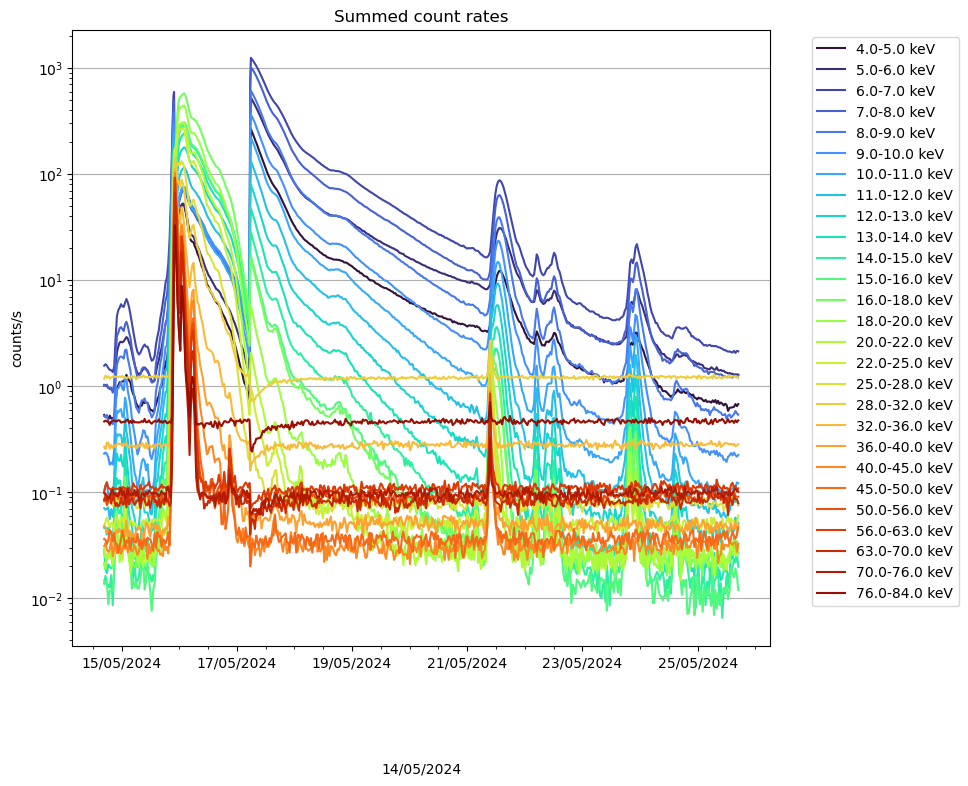

In [107]:
## Plot summed count rates in all energy bands

fig = plt.figure(figsize=(9,8),facecolor='w')
axes = fig.subplots(nrows=1,ncols=1)
cm = plt.get_cmap('turbo')
num_colors = summed_count_rates.shape[1]

for chan in range(summed_count_rates.shape[1]):
    lines = axes.plot(hxr_dates,summed_count_rates[:,chan],label=energy_labels[chan])
    lines[0].set_color(cm(1.*chan/num_colors))

axes.minorticks_on()
axes.yaxis.set_minor_locator(mticker.MultipleLocator(5))
axes.set_yscale("log")
axes.set_ylabel('counts/s')
axes.yaxis.grid(True, 'major')
date_format = plt_dates.DateFormatter('%d/%m/%Y')
axes.xaxis.set_major_formatter(date_format)
axes.text(0.5, -0.2, datetime.date(time_arr[0]).strftime("%d/%m/%Y"), ha='center', va='center',
        transform=axes.transAxes)
axes.set_title('Summed count rates')
axes.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [108]:
## To produce lightcurves in larger energy bands, for instance two lightcurves in ranges 5-7 keV and 14-28 keV:

import numpy as np

e_low = 5 #keV
e_high = 7 #keV
energy_idx = np.where((hdulist[4].data['e_low']>=e_low) & (hdulist[4].data['e_high']<=e_high))[0]
count_rate_thermal = count_rate[:,:,:,energy_idx].sum(axis=1).sum(axis=1).sum(axis=1)

e_low = 14 #keV
e_high = 28 #keV
energy_idx = np.where((hdulist[4].data['e_low']>=e_low) & (hdulist[4].data['e_high']<=e_high))[0]
count_rate_nonthermal = count_rate[:,:,:,energy_idx].sum(axis=1).sum(axis=1).sum(axis=1)


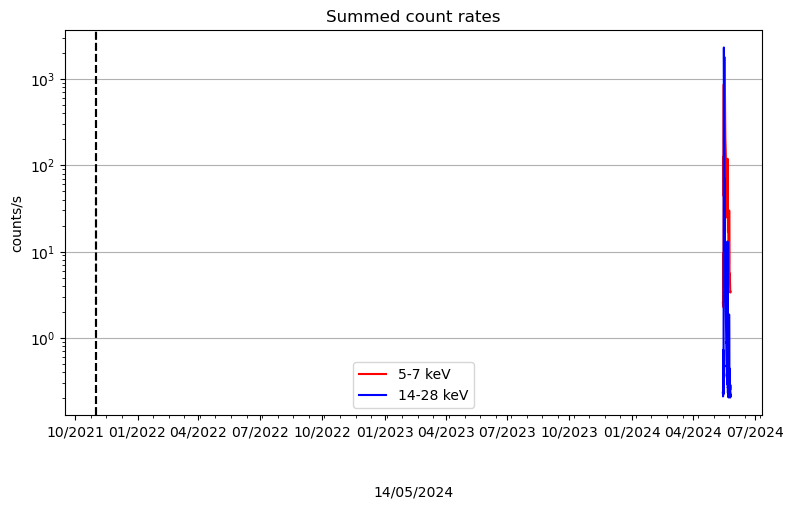

In [113]:
## Plot them:

fig = plt.figure(figsize=(9,5),facecolor='w')
axes = fig.subplots(nrows=1,ncols=1)

imagetime1 = datetime(2021,11,1,1,28,0)
imagetime2 = datetime(2021,11,1,1,29,0)

lines = axes.plot(hxr_dates,count_rate_thermal,label='5-7 keV')
lines[0].set_color('red')
lines = axes.plot(hxr_dates,count_rate_nonthermal,label='14-28 keV')
lines[0].set_color('blue')

axes.minorticks_on()
axes.yaxis.set_minor_locator(mticker.MultipleLocator(5))
axes.set_yscale("log")
axes.set_ylabel('counts/s')
axes.yaxis.grid(True, 'major')
date_format = plt_dates.DateFormatter('%m/%Y')
axes.xaxis.set_major_formatter(date_format)
axes.text(0.5, -0.2, datetime.date(time_arr[0]).strftime("%d/%m/%Y"), ha='center', va='center',
        transform=axes.transAxes)
axes.set_title('Summed count rates')
plt.legend(loc='best')
plt.axvline(x=imagetime1, linestyle='--', color='black')
plt.axvline(x=imagetime2, linestyle='--', color='black')
plt.show()